In [15]:
image = cv2.imread("gambar.jpg", 0)

NameError: name 'cv2' is not defined

=== PRAKTIKUM 4: PENINGKATAN KUALITAS CITRA ===
Materi: Point Processing, Histogram Analysis, Contrast Enhancement


1. POINT PROCESSING TRANSFORMATIONS


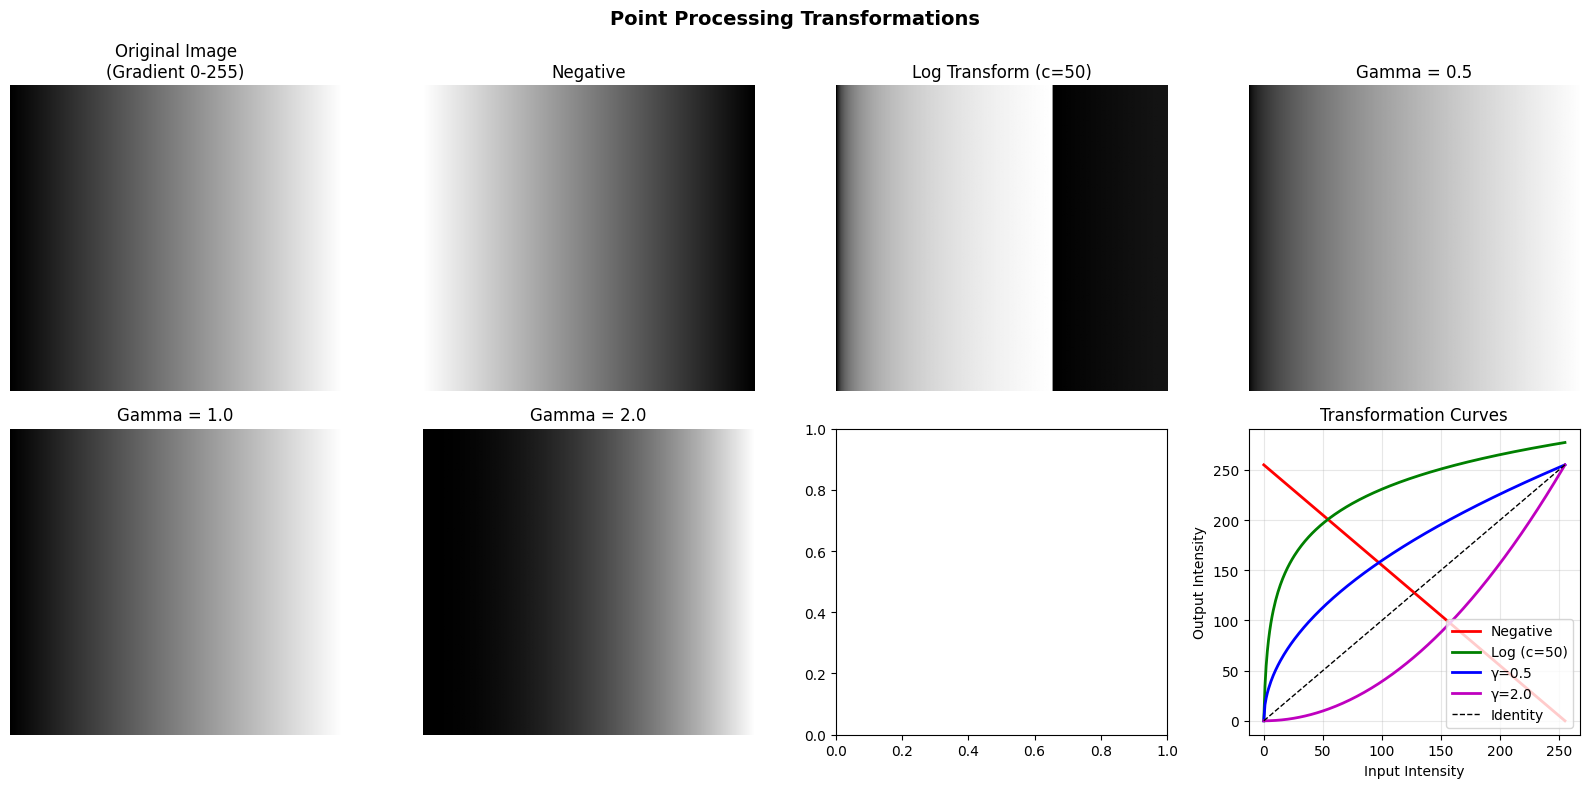


2. HISTOGRAM ANALYSIS AND EQUALIZATION


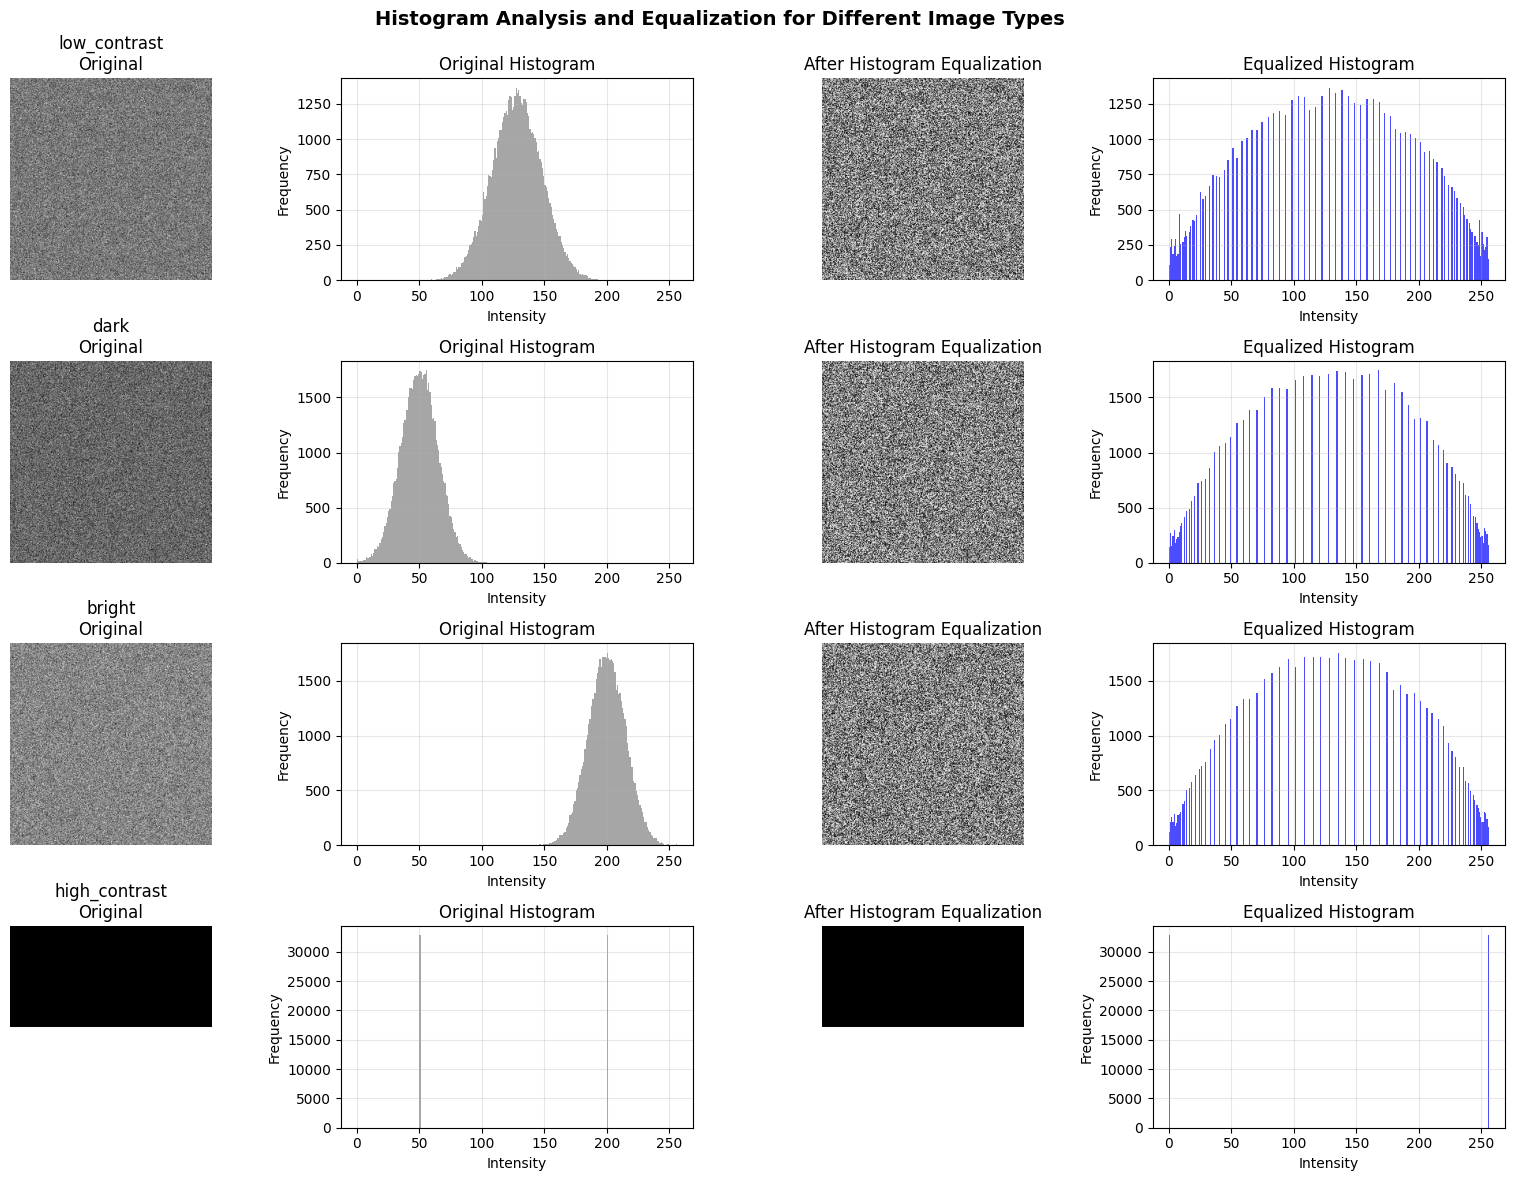


3. CONTRAST STRETCHING AND NORMALIZATION


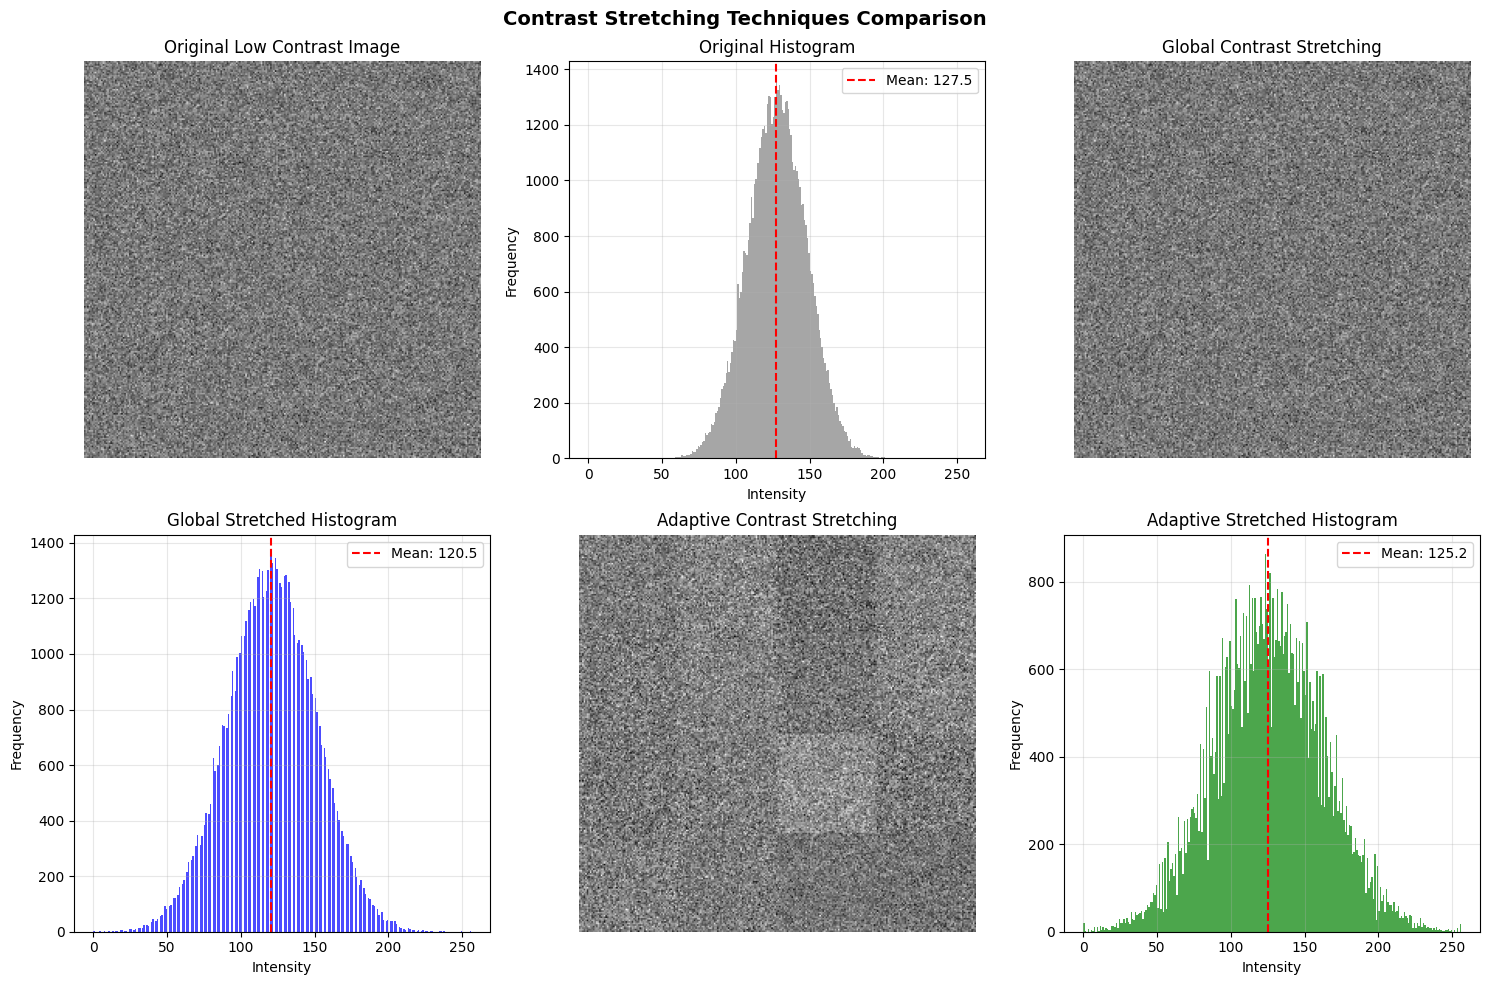


Statistics Comparison:
Metric               Original        Global          Adaptive       
------------------------------------------------------------
mean                 127.48          120.46          125.19         
std                  20.01           30.01           36.95          
min                  47.00           0.00            0.00           
max                  217.00          255.00          255.00         
dynamic_range        170.00          255.00          255.00         
entropy              4.41            4.41            5.01           

4. CLAHE - CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION


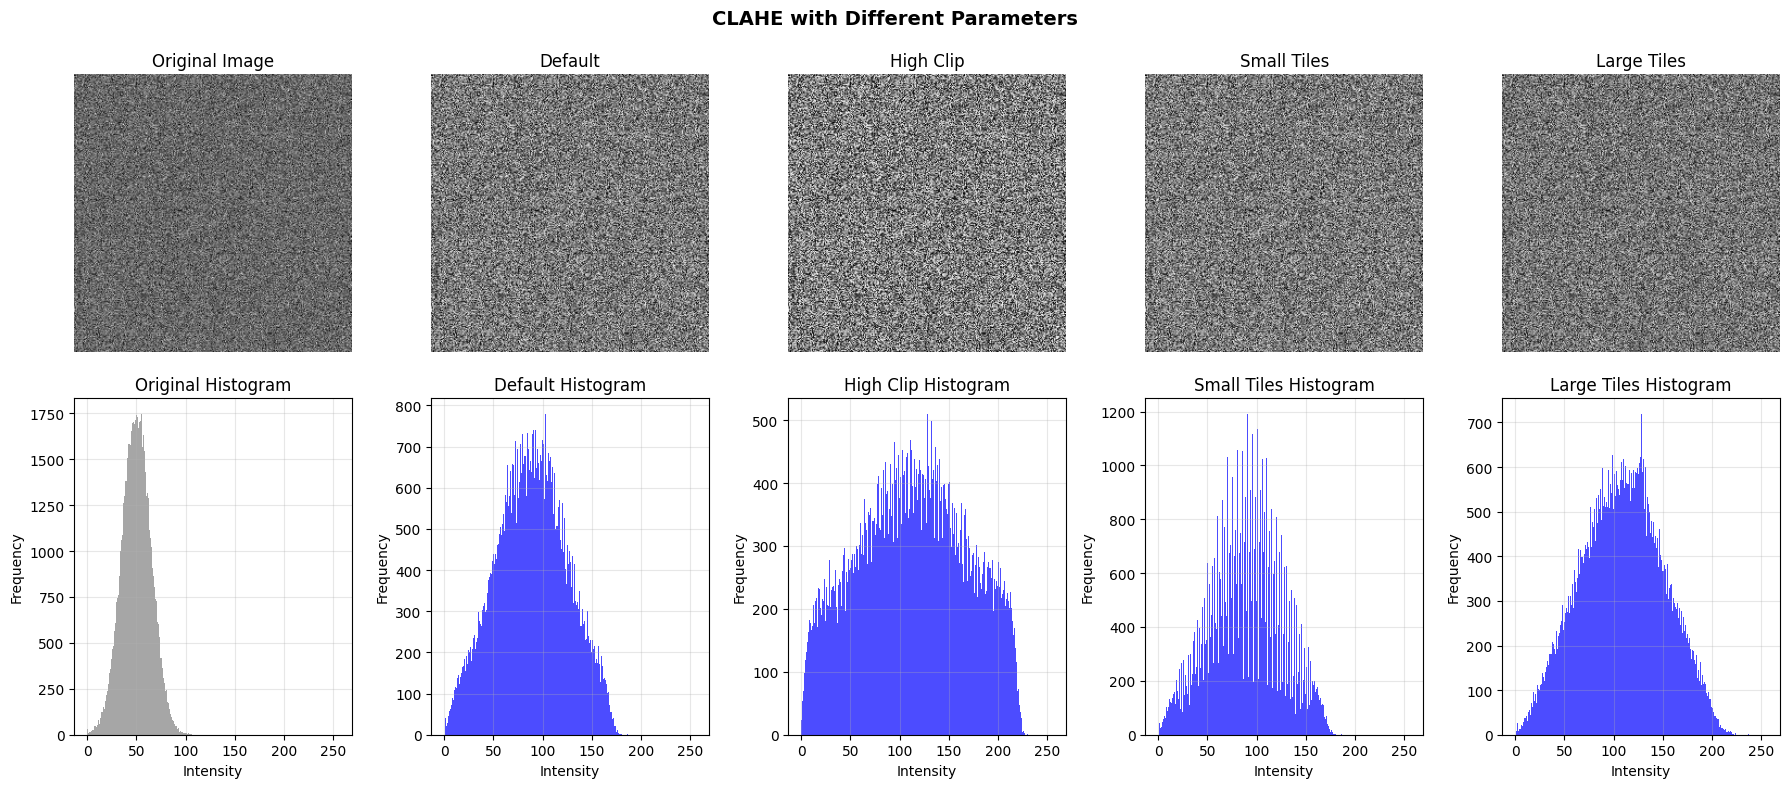


5. COMPREHENSIVE ENHANCEMENT PIPELINE


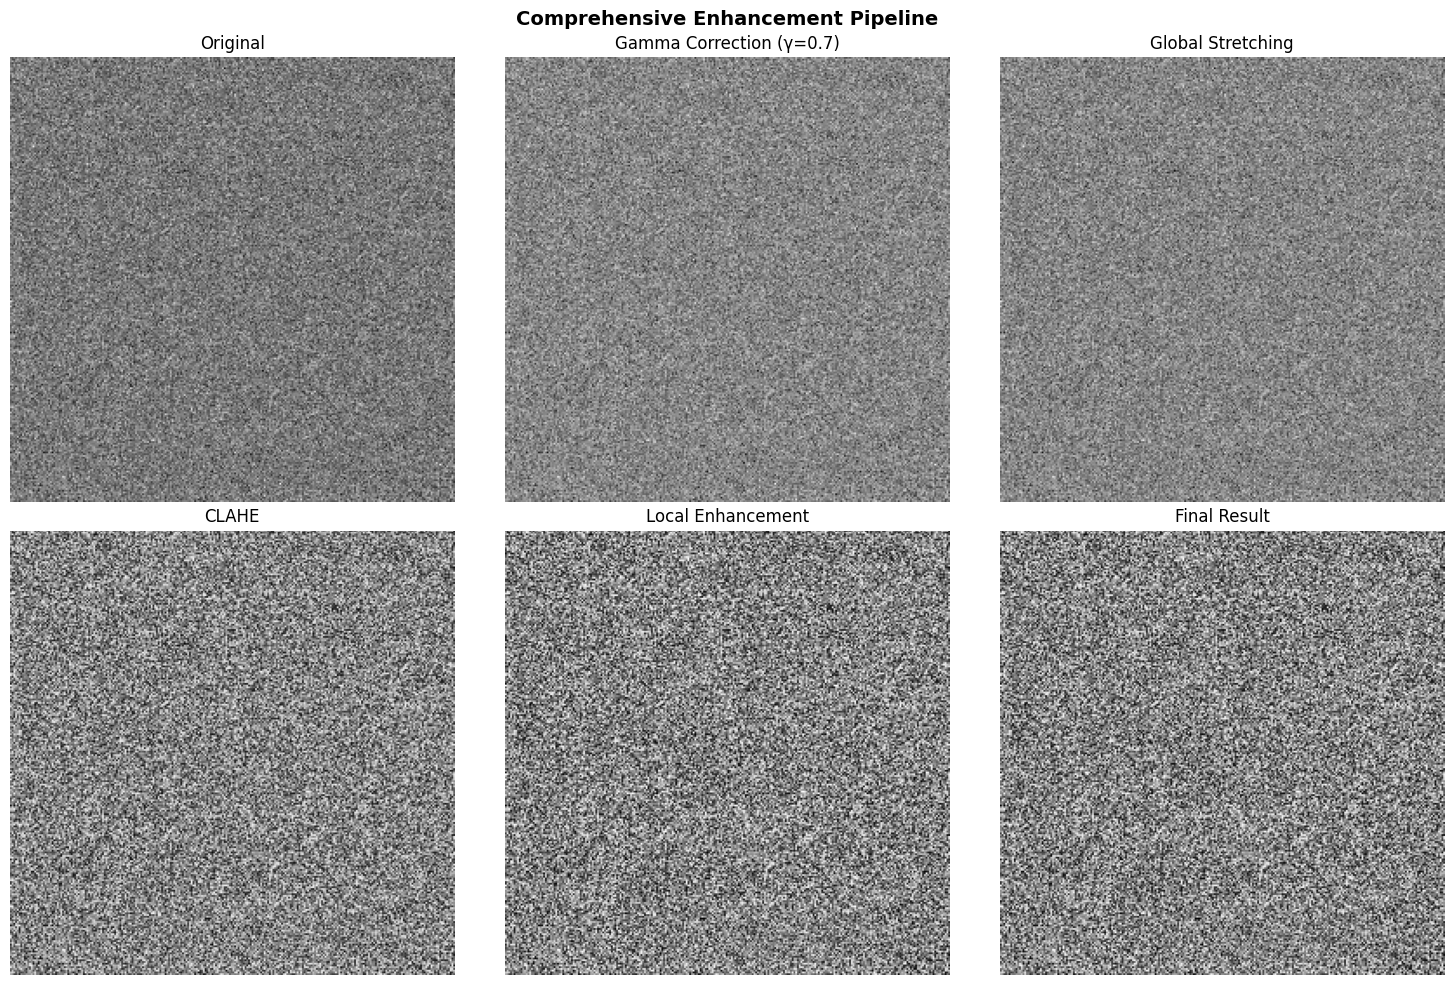


Enhancement Pipeline Metrics:
Step                      Mean       Std        Min        Max        Entropy   
----------------------------------------------------------------------
Original                  127.48     20.01      47.00      217.00     4.4137    
Gamma Correction (γ=0.7)  156.04     17.33      78.00      227.00     4.2280    
Global Stretching         133.07     29.67      0.00       255.00     4.2280    
CLAHE                     133.01     54.55      1.00       255.00     5.3444    
Local Enhancement         131.91     59.00      0.00       255.00     5.4251    
Final Result              131.91     59.00      0.00       255.00     5.4251    

6. QUALITY METRICS FOR ENHANCEMENT EVALUATION

Enhancement Methods Evaluation:
Method                    CII        Entropy Δ    MSE        PSNR (dB)    Info Ratio
--------------------------------------------------------------------------------
Histogram Equalization    3.678      -0.0618      2940.23    13.45        0.986     


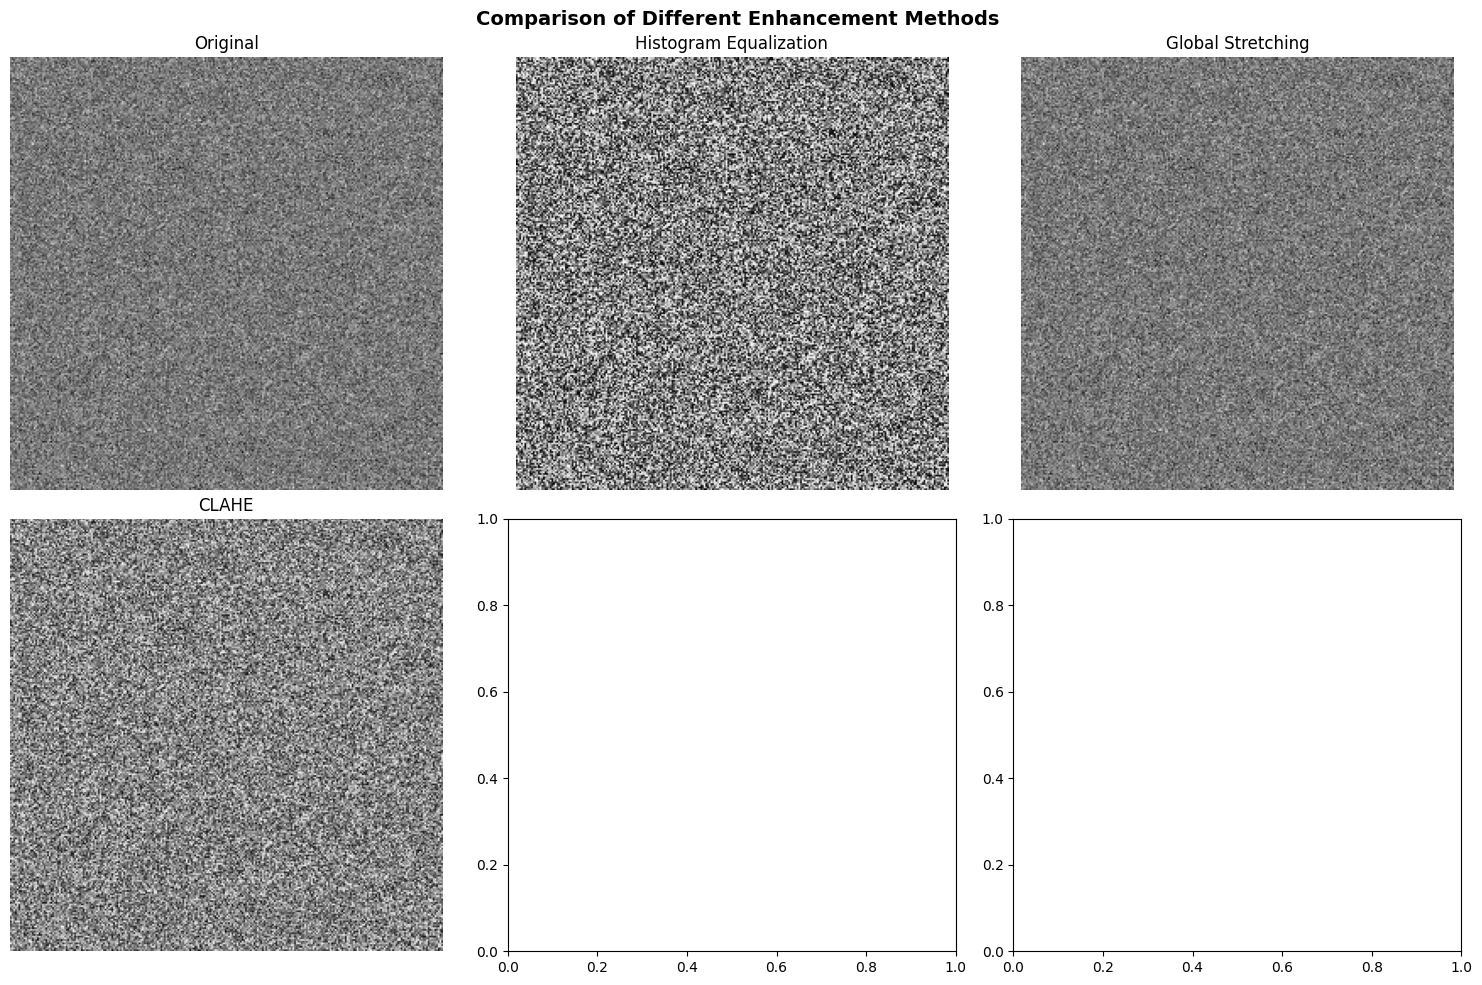


=== PRAKTIKUM SELESAI ===

Ringkasan yang dipelajari:
1. Point processing: negative, log, power-law transformations
2. Histogram analysis and equalization techniques
3. Contrast stretching and normalization methods
4. Local vs global enhancement strategies
5. CLAHE and comprehensive enhancement pipelines
6. Quality metrics for enhancement evaluation


In [ ]:
# ============================================
# PRAKTIKUM 4: PENINGKATAN KUALITAS CITRA
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=== PRAKTIKUM 4: PENINGKATAN KUALITAS CITRA ===")
print("Materi: Point Processing, Histogram Analysis, Contrast Enhancement\n")

# =============== FUNGSI BANTU ===============
def load_sample_images():
    """Load sample images with different characteristics"""
    images = {}
    
    # Create synthetic images
    size = 256
    
    # 1. Low contrast image
    low_contrast = np.random.normal(128, 20, (size, size))
    low_contrast = np.clip(low_contrast, 0, 255).astype(np.uint8)
    images['low_contrast'] = low_contrast
    
    # 2. Dark image
    dark = np.random.normal(50, 15, (size, size))
    dark = np.clip(dark, 0, 255).astype(np.uint8)
    images['dark'] = dark
    
    # 3. Bright image
    bright = np.random.normal(200, 15, (size, size))
    bright = np.clip(bright, 0, 255).astype(np.uint8)
    images['bright'] = bright
    
    # 4. High contrast image
    high_contrast = np.zeros((size, size), dtype=np.uint8)
    high_contrast[:size//2, :] = 50
    high_contrast[size//2:, :] = 200
    images['high_contrast'] = high_contrast
    
    return images

def analyze_image_statistics(image, name):
    """Calculate image statistics"""
    stats_dict = {
        'name': name,
        'mean': np.mean(image),
        'std': np.std(image),
        'min': np.min(image),
        'max': np.max(image),
        'dynamic_range': np.max(image) - np.min(image),
        'entropy': stats.entropy(np.histogram(image.flatten(), 256, [0,256])[0])
    }
    return stats_dict

# =============== MAIN PRAKTIKUM ===============

# 1. POINT PROCESSING TRANSFORMATIONS
print("\n1. POINT PROCESSING TRANSFORMATIONS")

# Create test image
test_image = np.linspace(0, 255, 256).astype(np.uint8)
test_image = np.tile(test_image, (100, 1))

# Define transformation functions
def negative_transform(image):
    return 255 - image

def log_transform(image, c=255/np.log(256)):
    image_float = image.astype(np.float32) + 1  # Avoid log(0)
    return (c * np.log(image_float)).astype(np.uint8)

def power_law_transform(image, gamma=1.0, c=1.0):
    image_float = image.astype(np.float32) / 255.0
    transformed = c * np.power(image_float, gamma)
    return (transformed * 255).astype(np.uint8)

# Apply transformations
negative_result = negative_transform(test_image)
log_result = log_transform(test_image, c=50)
gamma_05 = power_law_transform(test_image, gamma=0.5)
gamma_10 = power_law_transform(test_image, gamma=1.0)
gamma_20 = power_law_transform(test_image, gamma=2.0)

# Visualize transformations
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(test_image, cmap='gray', aspect='auto')
axes[0, 0].set_title('Original Image\n(Gradient 0-255)')
axes[0, 0].axis('off')

# Transformation results
results = [
    ('Negative', negative_result),
    ('Log Transform (c=50)', log_result),
    ('Gamma = 0.5', gamma_05),
    ('Gamma = 1.0', gamma_10),
    ('Gamma = 2.0', gamma_20)
]

for idx, (title, img) in enumerate(results[:3], 1):
    axes[0, idx].imshow(img, cmap='gray', aspect='auto')
    axes[0, idx].set_title(title)
    axes[0, idx].axis('off')

for idx, (title, img) in enumerate(results[3:], 0):
    axes[1, idx].imshow(img, cmap='gray', aspect='auto')
    axes[1, idx].set_title(title)
    axes[1, idx].axis('off')

# Plot transformation curves
x = np.linspace(0, 255, 256)
axes[1, 3].plot(x, 255-x, 'r-', label='Negative', linewidth=2)
axes[1, 3].plot(x, 50*np.log(x+1), 'g-', label='Log (c=50)', linewidth=2)
axes[1, 3].plot(x, 255*(x/255)**0.5, 'b-', label='γ=0.5', linewidth=2)
axes[1, 3].plot(x, 255*(x/255)**2.0, 'm-', label='γ=2.0', linewidth=2)
axes[1, 3].plot(x, x, 'k--', label='Identity', linewidth=1)
axes[1, 3].set_title('Transformation Curves')
axes[1, 3].set_xlabel('Input Intensity')
axes[1, 3].set_ylabel('Output Intensity')
axes[1, 3].legend()
axes[1, 3].grid(True, alpha=0.3)

plt.suptitle('Point Processing Transformations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. HISTOGRAM ANALYSIS AND EQUALIZATION
print("\n2. HISTOGRAM ANALYSIS AND EQUALIZATION")

# Load sample images with different characteristics
sample_images = load_sample_images()

# Apply histogram equalization
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for idx, (img_name, image) in enumerate(sample_images.items()):
    row = idx
    
    # Original image
    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].set_title(f'{img_name}\nOriginal')
    axes[row, 0].axis('off')
    
    # Original histogram
    axes[row, 1].hist(image.ravel(), 256, [0, 256], color='gray', alpha=0.7)
    axes[row, 1].set_title('Original Histogram')
    axes[row, 1].set_xlabel('Intensity')
    axes[row, 1].set_ylabel('Frequency')
    axes[row, 1].grid(True, alpha=0.3)
    
    # Apply histogram equalization
    equalized = cv2.equalizeHist(image)
    
    # Equalized image
    axes[row, 2].imshow(equalized, cmap='gray')
    axes[row, 2].set_title('After Histogram Equalization')
    axes[row, 2].axis('off')
    
    # Equalized histogram
    axes[row, 3].hist(equalized.ravel(), 256, [0, 256], color='blue', alpha=0.7)
    axes[row, 3].set_title('Equalized Histogram')
    axes[row, 3].set_xlabel('Intensity')
    axes[row, 3].set_ylabel('Frequency')
    axes[row, 3].grid(True, alpha=0.3)

plt.suptitle('Histogram Analysis and Equalization for Different Image Types', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. CONTRAST STRETCHING TECHNIQUES
print("\n3. CONTRAST STRETCHING AND NORMALIZATION")

def contrast_stretching(image, r_min=None, r_max=None):
    """Apply contrast stretching"""
    if r_min is None:
        r_min = np.min(image)
    if r_max is None:
        r_max = np.max(image)
    
    # Avoid division by zero
    if r_max == r_min:
        return image
    
    # Apply contrast stretching
    stretched = ((image.astype(float) - r_min) / (r_max - r_min) * 255).astype(np.uint8)
    return stretched

def adaptive_contrast_stretching(image, window_size=32):
    """Apply local contrast stretching"""
    h, w = image.shape
    result = np.zeros_like(image, dtype=np.float32)
    
    for i in range(0, h, window_size):
        for j in range(0, w, window_size):
            # Extract local window
            i_end = min(i + window_size, h)
            j_end = min(j + window_size, w)
            window = image[i:i_end, j:j_end]
            
            # Apply contrast stretching locally
            if window.size > 0:
                local_min = np.min(window)
                local_max = np.max(window)
                
                if local_max > local_min:
                    window_stretched = ((window.astype(float) - local_min) / 
                                       (local_max - local_min) * 255)
                else:
                    window_stretched = window.astype(float)
                
                result[i:i_end, j:j_end] = window_stretched
    
    return result.astype(np.uint8)

# Test on low contrast image
low_contrast_img = sample_images['low_contrast']

# Apply different contrast stretching methods
global_stretched = contrast_stretching(low_contrast_img)
adaptive_stretched = adaptive_contrast_stretching(low_contrast_img, window_size=64)

# Calculate statistics
original_stats = analyze_image_statistics(low_contrast_img, 'Original')
global_stats = analyze_image_statistics(global_stretched, 'Global Stretching')
adaptive_stats = analyze_image_statistics(adaptive_stretched, 'Adaptive Stretching')

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original image and histogram
axes[0, 0].imshow(low_contrast_img, cmap='gray')
axes[0, 0].set_title('Original Low Contrast Image')
axes[0, 0].axis('off')

axes[0, 1].hist(low_contrast_img.ravel(), 256, [0, 256], color='gray', alpha=0.7)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(original_stats['mean'], color='red', linestyle='--', label=f"Mean: {original_stats['mean']:.1f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Global contrast stretching
axes[0, 2].imshow(global_stretched, cmap='gray')
axes[0, 2].set_title('Global Contrast Stretching')
axes[0, 2].axis('off')

axes[1, 0].hist(global_stretched.ravel(), 256, [0, 256], color='blue', alpha=0.7)
axes[1, 0].set_title('Global Stretched Histogram')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(global_stats['mean'], color='red', linestyle='--', label=f"Mean: {global_stats['mean']:.1f}")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Adaptive contrast stretching
axes[1, 1].imshow(adaptive_stretched, cmap='gray')
axes[1, 1].set_title('Adaptive Contrast Stretching')
axes[1, 1].axis('off')

axes[1, 2].hist(adaptive_stretched.ravel(), 256, [0, 256], color='green', alpha=0.7)
axes[1, 2].set_title('Adaptive Stretched Histogram')
axes[1, 2].set_xlabel('Intensity')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].axvline(adaptive_stats['mean'], color='red', linestyle='--', label=f"Mean: {adaptive_stats['mean']:.1f}")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Contrast Stretching Techniques Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics comparison
print("\nStatistics Comparison:")
print("="*60)
print(f"{'Metric':<20} {'Original':<15} {'Global':<15} {'Adaptive':<15}")
print("-"*60)
for metric in ['mean', 'std', 'min', 'max', 'dynamic_range', 'entropy']:
    print(f"{metric:<20} {original_stats[metric]:<15.2f} {global_stats[metric]:<15.2f} {adaptive_stats[metric]:<15.2f}")

# 4. CLAHE (CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION)
print("\n4. CLAHE - CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION")

def demonstrate_clahe(image):
    """Demonstrate CLAHE with different parameters"""
    
    # Create CLAHE object with different parameters
    clahe_configs = [
        ('Default', cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))),
        ('High Clip', cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))),
        ('Small Tiles', cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))),
        ('Large Tiles', cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16)))
    ]
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    
    # Original image and histogram
    axes[0, 0].imshow(image, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[1, 0].hist(image.ravel(), 256, [0, 256], color='gray', alpha=0.7)
    axes[1, 0].set_title('Original Histogram')
    axes[1, 0].set_xlabel('Intensity')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Apply different CLAHE configurations
    for idx, (title, clahe) in enumerate(clahe_configs, 1):
        clahe_result = clahe.apply(image)
        
        # Display CLAHE result
        axes[0, idx].imshow(clahe_result, cmap='gray')
        axes[0, idx].set_title(title)
        axes[0, idx].axis('off')
        
        # Display histogram
        axes[1, idx].hist(clahe_result.ravel(), 256, [0, 256], color='blue', alpha=0.7)
        axes[1, idx].set_title(f'{title} Histogram')
        axes[1, idx].set_xlabel('Intensity')
        axes[1, idx].set_ylabel('Frequency')
        axes[1, idx].grid(True, alpha=0.3)
    
    plt.suptitle('CLAHE with Different Parameters', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return clahe_configs

# Apply CLAHE to dark image
dark_image = sample_images['dark']
clahe_configs = demonstrate_clahe(dark_image)

# 5. COMPREHENSIVE ENHANCEMENT PIPELINE
print("\n5. COMPREHENSIVE ENHANCEMENT PIPELINE")

def comprehensive_enhancement_pipeline(image):
    """Demonstrate a complete enhancement pipeline"""
    
    results = {}
    
    # Step 1: Gamma Correction (pre-processing)
    gamma_corrected = power_law_transform(image, gamma=0.7)
    results['gamma_correction'] = gamma_corrected
    
    # Step 2: Global Contrast Stretching
    global_stretched = contrast_stretching(gamma_corrected)
    results['global_stretching'] = global_stretched
    
    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    clahe_result = clahe.apply(global_stretched)
    results['clahe'] = clahe_result
    
    # Step 4: Local Enhancement (adaptive stretching)
    local_enhanced = adaptive_contrast_stretching(clahe_result, window_size=32)
    results['local_enhancement'] = local_enhanced
    
    # Step 5: Final normalization
    final_normalized = cv2.normalize(local_enhanced, None, 0, 255, cv2.NORM_MINMAX)
    results['final'] = final_normalized
    
    return results

# Apply pipeline to test image
test_img = sample_images['low_contrast']
pipeline_results = comprehensive_enhancement_pipeline(test_img)

# Display pipeline results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

steps = [
    ('Original', test_img),
    ('Gamma Correction (γ=0.7)', pipeline_results['gamma_correction']),
    ('Global Stretching', pipeline_results['global_stretching']),
    ('CLAHE', pipeline_results['clahe']),
    ('Local Enhancement', pipeline_results['local_enhancement']),
    ('Final Result', pipeline_results['final'])
]

for idx, (title, img) in enumerate(steps):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

plt.suptitle('Comprehensive Enhancement Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate and compare metrics
print("\nEnhancement Pipeline Metrics:")
print("="*70)
print(f"{'Step':<25} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Entropy':<10}")
print("-"*70)

for step_name, img in steps:
    img_stats = analyze_image_statistics(img, step_name)
    print(f"{step_name:<25} {img_stats['mean']:<10.2f} {img_stats['std']:<10.2f} "
          f"{img_stats['min']:<10.2f} {img_stats['max']:<10.2f} {img_stats['entropy']:<10.4f}")

# 6. QUALITY METRICS FOR ENHANCEMENT EVALUATION
print("\n6. QUALITY METRICS FOR ENHANCEMENT EVALUATION")

def calculate_enhancement_metrics(original, enhanced):
    """Calculate various enhancement quality metrics"""
    
    metrics = {}
    
    # 1. Contrast Improvement Index (CII)
    original_contrast = np.std(original)
    enhanced_contrast = np.std(enhanced)
    metrics['CII'] = enhanced_contrast / original_contrast if original_contrast > 0 else 0
    
    # 2. Entropy improvement
    orig_hist, _ = np.histogram(original.flatten(), 256, [0, 256])
    enh_hist, _ = np.histogram(enhanced.flatten(), 256, [0, 256])
    orig_entropy = stats.entropy(orig_hist + 1e-10)  # Add small value to avoid log(0)
    enh_entropy = stats.entropy(enh_hist + 1e-10)
    metrics['entropy_improvement'] = enh_entropy - orig_entropy
    
    # 3. PSNR (if we had ground truth)
    # For demonstration, we'll calculate between original and enhanced
    mse = np.mean((original.astype(float) - enhanced.astype(float)) ** 2)
    metrics['MSE'] = mse
    metrics['PSNR'] = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    
    # 4. Visual Information Fidelity (simplified)
    metrics['info_content_ratio'] = enh_entropy / orig_entropy if orig_entropy > 0 else 0
    
    return metrics

# Evaluate different enhancement methods
enhancement_methods = {
    'Histogram Equalization': cv2.equalizeHist(test_img),
    'Global Stretching': contrast_stretching(test_img),
    'CLAHE': cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(test_img),
    'Comprehensive Pipeline': pipeline_results['final']
}

print("\nEnhancement Methods Evaluation:")
print("="*80)
print(f"{'Method':<25} {'CII':<10} {'Entropy Δ':<12} {'MSE':<10} {'PSNR (dB)':<12} {'Info Ratio':<10}")
print("-"*80)

for method_name, enhanced_img in enhancement_methods.items():
    metrics = calculate_enhancement_metrics(test_img, enhanced_img)
    print(f"{method_name:<25} {metrics['CII']:<10.3f} {metrics['entropy_improvement']:<12.4f} "
          f"{metrics['MSE']:<10.2f} {metrics['PSNR']:<12.2f} {metrics['info_content_ratio']:<10.3f}")

# Visual comparison of all methods
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

methods_list = list(enhancement_methods.items())
for idx in range(min(6, len(methods_list))):
    row = idx // 3
    col = idx % 3
    
    if idx == 0:
        axes[row, col].imshow(test_img, cmap='gray')
        axes[row, col].set_title('Original')
    else:
        method_name, enhanced_img = methods_list[idx-1]
        axes[row, col].imshow(enhanced_img, cmap='gray')
        axes[row, col].set_title(method_name)
    
    axes[row, col].axis('off')

plt.suptitle('Comparison of Different Enhancement Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== PRAKTIKUM SELESAI ===")
print("\nRingkasan yang dipelajari:")
print("1. Point processing: negative, log, power-law transformations")
print("2. Histogram analysis and equalization techniques")
print("3. Contrast stretching and normalization methods")
print("4. Local vs global enhancement strategies")
print("5. CLAHE and comprehensive enhancement pipelines")
print("6. Quality metrics for enhancement evaluation")